In [84]:

#IMPORTAR LIBRERÍAS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [85]:

#CARGAR LA BASE DE DATOS

url = 'https://raw.githubusercontent.com/MaximilianoVE/Grupo_5_Proyecto_social-/refs/heads/main/Datos_info/data_habitacional.csv'

df_modelo = pd.read_csv(url)

df_modelo.head()

,DESTINO,SEXO,INGRESO_$,ENDEUDAMIENTO,PROGRAMA,EDAD_AÑO,MONTO_OTORGADO_$,FINANCIAMIENTO_INMUEBLE,Plazo_MESES
0,Construcción de vivienda,F,697.00,36.93,Clase social,18,"32,333.00",97%,360
1,Construcción de vivienda,F,"1,136.00",40.98,Clase social,18,"25,926.00",85%,240
2,Construcción de vivienda,F,"1,183.00",40.96,Clase social,18,"48,148.00",55%,360
3,Construcción de vivienda,F,647.00,41.87,Clase social,23,"21,111.00",95%,240
4,Construcción de vivienda,M,"2,506.00",39.28,Clase media,24,"78,685.00",81%,360


In [86]:

#EXPLORACIÓN INICIAL

print("Dimensiones de la base:", df_modelo.shape)
print("\nTipos de datos:")
display(df_modelo.dtypes)

print("\nValores nulos por columna:")
display(df_modelo.isna().sum())

Dimensiones de la base: (866, 9)

Tipos de datos:


,0
DESTINO,object
SEXO,object
INGRESO_$,object
ENDEUDAMIENTO,float64
PROGRAMA,object
EDAD_AÑO,int64
MONTO_OTORGADO_$,object
FINANCIAMIENTO_INMUEBLE,object
Plazo_MESES,int64



Valores nulos por columna:


,0
DESTINO,0
SEXO,0
INGRESO_$,0
ENDEUDAMIENTO,0
PROGRAMA,0
EDAD_AÑO,0
MONTO_OTORGADO_$,0
FINANCIAMIENTO_INMUEBLE,0
Plazo_MESES,0


In [87]:

#ESTADÍSTICA DESCRIPTIVA

display(df_modelo.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
DESTINO,866,2,Construcción de vivienda,617,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SEXO,866,2,M,435,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INGRESO_$,866,586,"1,037.00",12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENDEUDAMIENTO,866.0,NaN,NaN,NaN,42.020889,10.978144,0.0,34.485,41.25,49.03,115.67
PROGRAMA,866,2,Clase social,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EDAD_AÑO,866.0,NaN,NaN,NaN,36.290993,7.72674,18.0,31.0,35.0,40.0,71.0
MONTO_OTORGADO_$,866,314,"48,148.00",161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FINANCIAMIENTO_INMUEBLE,866,67,100%,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Plazo_MESES,866.0,NaN,NaN,NaN,334.351039,49.208901,120.0,360.0,360.0,360.0,401.0


In [88]:

#PREPARAR LA BASE PARA EL MODELO

# Convertir variables a numérico
df_modelo["MONTO_OTORGADO_$"] = (
    df_modelo["MONTO_OTORGADO_$"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)

df_modelo["MONTO_OTORGADO_$"] = pd.to_numeric(df_modelo["MONTO_OTORGADO_$"], errors="coerce")

df_modelo["INGRESO_$"] = (
    df_modelo["INGRESO_$"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)

df_modelo["INGRESO_$"] = pd.to_numeric(df_modelo["INGRESO_$"], errors="coerce")

df_modelo["FINANCIAMIENTO_INMUEBLE"] = (
    df_modelo["FINANCIAMIENTO_INMUEBLE"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.replace("%", "", regex=False)
    .str.strip()
)

df_modelo["FINANCIAMIENTO_INMUEBLE"] = pd.to_numeric(
    df_modelo["FINANCIAMIENTO_INMUEBLE"],
    errors="coerce"
)

# Revisar si hubo valores nulos después de convertir
print(df_modelo["MONTO_OTORGADO_$"].isna().sum())

# Si existieran nulos, los eliminamos
df_modelo = df_modelo.dropna(subset=["MONTO_OTORGADO_$"])

# Variable objetivo
y = df_modelo["MONTO_OTORGADO_$"]

# Variables predictoras
X = df_modelo.drop(columns=["MONTO_OTORGADO_$"])

print("Variables predictoras:")
display(X.columns)

0
Variables predictoras:


Index(['DESTINO', 'SEXO', 'INGRESO_$', 'ENDEUDAMIENTO', 'PROGRAMA', 'EDAD_AÑO',
       'FINANCIAMIENTO_INMUEBLE', 'Plazo_MESES'],
      dtype='object')

In [89]:
print(df_modelo.dtypes)

DESTINO                     object
SEXO                        object
INGRESO_$                  float64
ENDEUDAMIENTO              float64
PROGRAMA                    object
EDAD_AÑO                     int64
MONTO_OTORGADO_$           float64
FINANCIAMIENTO_INMUEBLE      int64
Plazo_MESES                  int64
dtype: object


In [90]:

#IDENTIFICAR VARIABLES NUMÉRICAS Y CATEGÓRICAS

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns

print("Variables numéricas:")
display(num_cols)

print("Variables categóricas:")
display(cat_cols)

Variables numéricas:


Index(['INGRESO_$', 'ENDEUDAMIENTO', 'EDAD_AÑO', 'FINANCIAMIENTO_INMUEBLE',
       'Plazo_MESES'],
      dtype='object')

Variables categóricas:


Index(['DESTINO', 'SEXO', 'PROGRAMA'], dtype='object')

In [91]:

#DIVISIÓN 80% ENTRENAMIENTO Y 20% PRUEBA

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (692, 8)
X_test : (174, 8)
y_train: (692,)
y_test : (174,)


In [92]:

#PREPROCESAMIENTO

transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", transformador_numerico, num_cols),
    ("cat", transformador_categorico, cat_cols)
])

In [93]:

#ENTRENAR VARIOS MODELOS

modelos = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42
    ),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42)
}

resultados = []

for nombre, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)

    resultados.append({
        "Modelo": nombre,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

resultados_df = pd.DataFrame(resultados).sort_values("R2", ascending=False)
display(resultados_df)

,Modelo,MAE,RMSE,R2
1,RandomForestRegressor,8210.062253,14483.174410,0.787890
2,GradientBoostingRegressor,9131.999419,14528.986952,0.786546
0,LinearRegression,16601.095956,21866.103192,0.516522


In [94]:
resultados_df = pd.DataFrame(resultados).sort_values("R2", ascending=False).reset_index(drop=True)
print(resultados_df)

                      Modelo           MAE          RMSE        R2
0      RandomForestRegressor   8210.062253  14483.174410  0.787890
1  GradientBoostingRegressor   9131.999419  14528.986952  0.786546
2           LinearRegression  16601.095956  21866.103192  0.516522


In [95]:
print(df_modelo.shape)
print(resultados_df)

(866, 9)
                      Modelo           MAE          RMSE        R2
0      RandomForestRegressor   8210.062253  14483.174410  0.787890
1  GradientBoostingRegressor   9131.999419  14528.986952  0.786546
2           LinearRegression  16601.095956  21866.103192  0.516522


In [96]:

#ENTRENAR EL MEJOR MODELO FINAL

mejor_modelo = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=42
    ))
])

mejor_modelo.fit(X_train, y_train)

pred_final = mejor_modelo.predict(X_test)

mae_final = mean_absolute_error(y_test, pred_final)
rmse_final = mean_squared_error(y_test, pred_final) ** 0.5
r2_final = r2_score(y_test, pred_final)

print("Resultados del modelo final:")
print("MAE :", mae_final)
print("RMSE:", rmse_final)
print("R2  :", r2_final)

Resultados del modelo final:
MAE : 8210.062252938527
RMSE: 14483.174409942243
R2  : 0.7878898911392289


In [97]:

#IMPORTANCIA DE VARIABLES

nombres_variables = mejor_modelo.named_steps["preprocessor"].get_feature_names_out()

importancias = pd.Series(
    mejor_modelo.named_steps["model"].feature_importances_,
    index=nombres_variables
).sort_values(ascending=False)

display(importancias.head(10))

,0
num__INGRESO_$,0.431030
cat__PROGRAMA_Clase social,0.153184
cat__PROGRAMA_Clase media,0.137887
num__FINANCIAMIENTO_INMUEBLE,0.091136
num__ENDEUDAMIENTO,0.078932
num__Plazo_MESES,0.044795
num__EDAD_AÑO,0.044150
cat__SEXO_F,0.005384
cat__SEXO_M,0.004687
cat__DESTINO_Compra de vivienda,0.004489


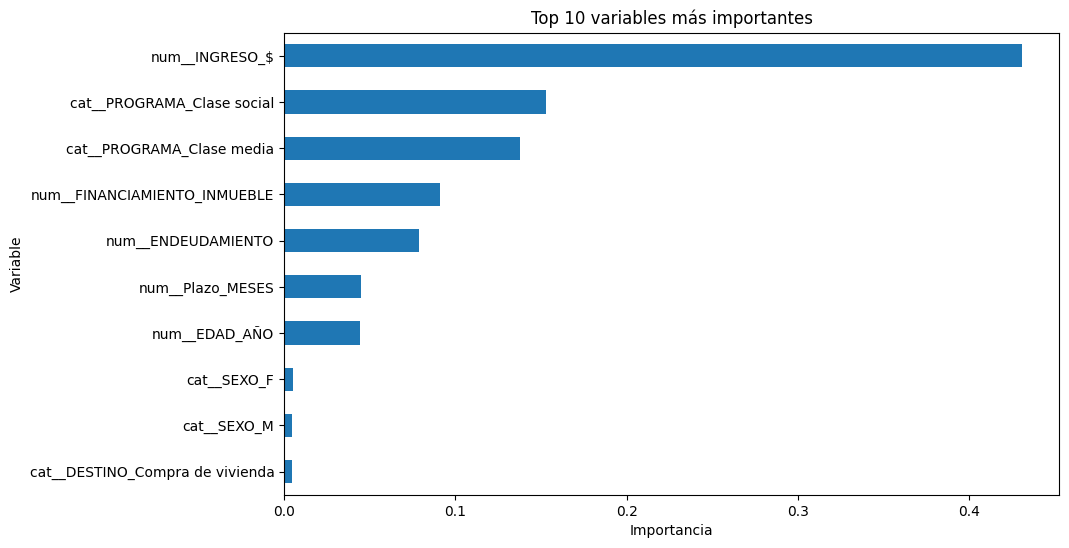

In [98]:

#GRÁFICO DE LAS 10 VARIABLES MÁS IMPORTANTES

importancias.head(10).sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Top 10 variables más importantes")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

In [99]:

#EJEMPLO DE PREDICCIÓN PARA UN NUEVO SOLICITANTE

nuevo_solicitante = pd.DataFrame({
    "DESTINO": ["Compra de vivienda"],
    "SEXO": ["F"],
    "INGRESO_$": [1800],
    "ENDEUDAMIENTO": [35.0],
    "PROGRAMA": ["Clase media"],
    "EDAD_AÑO": [32],
    "FINANCIAMIENTO_INMUEBLE": [0.90],
    "Plazo_MESES": [360]
})

nuevo_solicitante

,DESTINO,SEXO,INGRESO_$,ENDEUDAMIENTO,PROGRAMA,EDAD_AÑO,FINANCIAMIENTO_INMUEBLE,Plazo_MESES
0,Compra de vivienda,F,1800,35.0,Clase media,32,0.9,360


In [100]:

#PREDECIR EL MONTO OTORGADO

prediccion_monto = mejor_modelo.predict(nuevo_solicitante)[0]
print("Monto otorgado predicho: $", round(prediccion_monto, 2))

Monto otorgado predicho: $ 70533.64


In [101]:

#FUNCIÓN PARA PREDECIR NUEVOS CASOS

def predecir_monto(destino, sexo, ingreso, endeudamiento, programa, edad, financiamiento_inmueble, plazo_meses):
    nuevo = pd.DataFrame({
        "DESTINO": [destino],
        "SEXO": [sexo],
        "INGRESO_$": [ingreso],
        "ENDEUDAMIENTO": [endeudamiento],
        "PROGRAMA": [programa],
        "EDAD_AÑO": [edad],
        "FINANCIAMIENTO_INMUEBLE": [financiamiento_inmueble],
        "Plazo_MESES": [plazo_meses]
    })

    prediccion = mejor_modelo.predict(nuevo)[0]
    return prediccion

In [102]:

#MODELO DE PREDICCIÓN

monto_estimado = predecir_monto(
    destino="Compra de vivienda",
    sexo="M",
    ingreso=2200,
    endeudamiento=42.5,
    programa="Clase social",
    edad=40,
    financiamiento_inmueble=0.85,
    plazo_meses=300
)

print("Monto estimado: $", round(monto_estimado, 2))

Monto estimado: $ 25622.77
